### Import Libraries

In [1]:
#Import Libraries
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


### Load Data

In [2]:
#Create Data Generators
train_dir = './data/train'
val_dir = './data/val'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load training and validation sets
train_dataset = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_dataset = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 3724 images belonging to 5 classes.
Found 784 images belonging to 5 classes.


### Load Pretrained MobileNetV2

In [3]:
#Load Pretrained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base layers for feature extraction
for layer in base_model.layers:
    layer.trainable = False


### Add Custom Layers for the Dataset

In [4]:
#Add Custom Layers for the Dataset
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)

# Adjust 'num_classes' to dataset
num_classes = train_dataset.num_classes
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


### Compile and Train

In [5]:
#Compile and Train
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    verbose=1
)


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 186ms/step - accuracy: 0.6394 - loss: 0.9665 - val_accuracy: 0.8469 - val_loss: 0.4381
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 22s 186ms/step - accuracy: 0.8244 - loss: 0.4813 - val_accuracy: 0.8750 - val_loss: 0.3302
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 192ms/step - accuracy: 0.8440 - loss: 0.3922 - val_accuracy: 0.8929 - val_loss: 0.2922
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 22s 190ms/step - accuracy: 0.8719 - loss: 0.3304 - val_accuracy: 0.8954 - val_loss: 0.2736
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 193ms/step - accuracy: 0.8738 - loss: 0.3253 - val_accuracy: 0.9056 - val_loss: 0.2595
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.8837 - loss: 0.3001 - val_accuracy: 0.9082 - val_loss: 0.2511
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.8837 - loss: 0.2909 - val_accuracy: 0.9120 - val_loss: 0.2433
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 195ms/step - accuracy: 0.8915 - loss: 0

### Fine-Tune

In [ ]:
#Fine-Tune
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    verbose=1
)

### Save Model

In [6]:
model.save('mobilenetv2_plant_disease.h5')

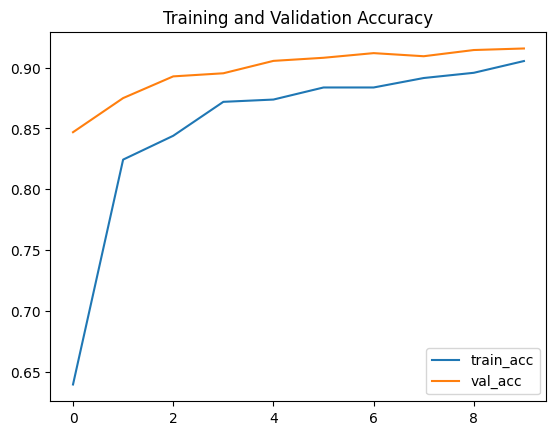

In [7]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

### Model Evaluation

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Evaluate the model on validation data
val_loss, val_acc = model.evaluate(val_dataset)
print(f"\n Validation Accuracy: {val_acc*100:.2f}%")
print(f" Validation Loss: {val_loss:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9158 - loss: 0.2293

✅ Validation Accuracy: 91.58%
📉 Validation Loss: 0.2293


<Figure size 1000x800 with 0 Axes>

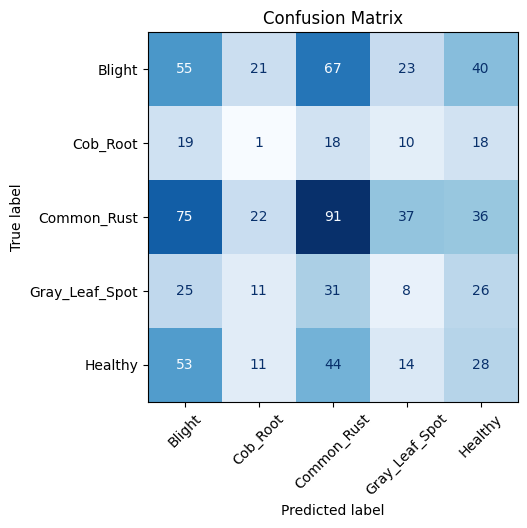

In [10]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix')
plt.show()

In [11]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels)


🔍 Classification Report:

                precision    recall  f1-score   support

        Blight       0.24      0.27      0.25       206
      Cob_Root       0.02      0.02      0.02        66
   Common_Rust       0.36      0.35      0.36       261
Gray_Leaf_Spot       0.09      0.08      0.08       101
       Healthy       0.19      0.19      0.19       150

      accuracy                           0.23       784
     macro avg       0.18      0.18      0.18       784
  weighted avg       0.23      0.23      0.23       784



### Conclusion

In this practise model I used a pretrained mobilenetv2 & added a fine tuning which improve the model accuracy compare to earlier one. 

*** Note: mobilenet also lightweight, faster which suitable to use in mobile apps